# 📡 5.2 1D-CNN Classification Model — Gated Pooling + AAontology

Este notebook explora una arquitectura basada en **Redes Neuronales Convolucionales de una dimensión (1D-CNN)** con **Gated Pooling guiado por AAontology** para la clasificación de los embeddings de proteínas generados por ProtFlash. A diferencia del MLP, la CNN busca identificar patrones locales o “motivos” a lo largo de la secuencia, mientras que el `AAontologyGatedPooler` pondera dinámicamente la contribución de cada residuo.

---

## 📋 Descripción general

El modelo recibe tres entradas:
- `X`: embeddings por residuo de ProtFlash, con forma `(B, L, 768)`.
- `Ont`: perfiles AAontology por residuo, con forma `(B, L, 8)`.
- `M`: máscara binaria, con forma `(B, L)`, usada para ignorar posiciones de padding.

La arquitectura `GatedConv1DClassifier`:
1. Genera una representación local `E_local` mediante `AAontologyGatedPooler`, usando `X`, `Ont` y `M`.
2. Procesa `X` con bloques `Conv1d` + `BatchNorm1d` + `GELU` + `Dropout1d`, aplicando la máscara `M`.
3. Genera características globales mediante *max pooling* enmascarado y *average pooling*.
4. Concatena las características convolucionales y `E_local`.
5. Procesa la representación combinada con un MLP y finaliza con una capa lineal de logits.

---

## 🛠️ Funcionalidades principales

1. **Arquitectura del modelo**
   - Bloques convolucionales 1D con `Conv1d`, `BatchNorm1d`, `GELU` y `Dropout1d`.
   - Pooling global mediante *max pooling* y *average pooling*.
   - `AAontologyGatedPooler` para integrar la ontología con los embeddings por residuo.
   - Combinación de características convolucionales y representación local guiada por AAontology.

2. **Entrenamiento y optimización**
   - Optimizador `AdamW` con *weight decay*.
   - Función de pérdida `FocalLoss` para manejar el desbalance de clases.
   - `ReduceLROnPlateau` para ajustar la tasa de aprendizaje.
   - *Early stopping* basado en la pérdida de validación.

3. **Búsqueda de hiperparámetros**
   - Evaluación de tres configuraciones: `CNN_Small`, `CNN_Medium` y `CNN_Large`.
   - Variación de canales convolucionales, tamaños de kernel, capas MLP, *dropout* y tasa de aprendizaje.

4. **Monitoreo y registro**
   - Registro por época de pérdida de entrenamiento/validación, accuracy, F1, MCC y ROC-AUC.
   - Guardado automático del mejor modelo según la menor pérdida de validación.
   - Exportación de checkpoints y métricas para comparación inter-modelo.

## 📦 Importación de librerías y entorno

In [1]:
import os
import json
import random
import time
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    matthews_corrcoef, confusion_matrix
)
import matplotlib.pyplot as plt

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.10.0+cu128
cuda available: True


## ⚙️ Configuración de rutas e hiperparámetros CNN

In [2]:
# ========== PATHS ==========
DATA_DIR = Path("/kaggle/input/datasets/user/new-final-dataset")
OUT_DIR = Path("/kaggle/working/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PT  = DATA_DIR / "train_dataset.pt"
VAL_PT    = DATA_DIR / "val_dataset.pt"
AAONTOLOGY_PATH = "/kaggle/input/datasets/user/new-aaontology/AAontology_zscored.pt"

# ========== HYPERPARAMETERS ==========
SEED        = 31
BATCH_SIZE  = 32
MAX_EPOCHS  = 100
PATIENCE    = 12       # Early stopping patience
MIN_DELTA   = 1e-4     # Minimum improvement for early stopping
INPUT_DIM   = 768      # Embeddings dimension
L_MAX       = 100
N_AA        = 20

# ========== ARCHITECTURES ==========
ARCHITECTURES = [
    {
        "name": "CNN_Small",
        "conv_channels": [128, 64],
        "kernel_sizes": [3, 5],
        "mlp_hidden": [128],
        "dropout": 0.3,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "CNN_Medium",
        "conv_channels": [256, 128],
        "kernel_sizes": [3, 5],
        "mlp_hidden": [128],
        "dropout": 0.4,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "CNN_Large",
        "conv_channels": [512, 256, 128],
        "kernel_sizes": [3, 5, 5],
        "mlp_hidden": [256, 128],
        "dropout": 0.4,
        "lr": 5e-4,  # Learning rate ligeramente menor para una red más grande
        "weight_decay": 1e-4,
    },
]

print(f"Architectures to compare: {len(ARCHITECTURES)}")
for cfg in ARCHITECTURES:
    print(f"  - {cfg['name']}: hidden={cfg['mlp_hidden']}, dropout={cfg['dropout']}")

Architectures to compare: 3
  - CNN_Small: hidden=[128], dropout=0.3
  - CNN_Medium: hidden=[128], dropout=0.4
  - CNN_Large: hidden=[256, 128], dropout=0.4


## 🖥️ Semilla para reproducibilidad y detección de dispositivo

In [3]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 🔬 Carga del tensor AAontology

In [4]:
# Carga el tensor (20, 8) precomputado con z-scores por categoría
if Path(AAONTOLOGY_PATH).exists():
    aa_data = torch.load(AAONTOLOGY_PATH, map_location="cpu", weights_only=True)
    AAONTOLOGY_ZSCORED = aa_data["tensor"]       # (21, 8)
    AA_ORDER = aa_data["amino_acids"]            # ['A', ..., 'Y', 'X']
    USED_CATEGORIES = aa_data["categories"]      # 8 categorías
else:
    raise FileNotFoundError(f"No se encontró {AAONTOLOGY_PATH}. Genera el tensor primero.")

AA_TO_IDX = {aa: i for i, aa in enumerate(AA_ORDER)}
N_CAT = AAONTOLOGY_ZSCORED.shape[1]

print(f"AAontology tensor: {AAONTOLOGY_ZSCORED.shape}")
print(f"Categorías: {USED_CATEGORIES}")

AAontology tensor: torch.Size([21, 8])
Categorías: ['ASA/Volume', 'Composition', 'Conformation', 'Energy', 'Polarity', 'Shape', 'Structure-Activity', 'Others']


## 📂 Definición de la clase `AMPDataset`

In [5]:
class AMPDataset(Dataset):
    """
    Estructura por muestra:
        X:   torch.FloatTensor (L_max, 768)  — ProtFlash embeddings
        G:   torch.FloatTensor (L_max, 8)    — AAontology features
        M:   torch.FloatTensor (L_max,)      — binary mask
        seq: str                             — AA sequence (for AAontology)
        y:   torch.FloatTensor (1,)          — label
    """
    def __init__(self, X, G, M, sequences, labels):
        self.X = torch.from_numpy(X).float()          # (N, L_max, 768)
        self.G = torch.from_numpy(G).float()          # (N, L_max, 8)
        assert self.G.shape[-1] == 8, f"Se esperaban 8 categorías de ontología, pero G tiene shape {self.G.shape}"
        self.M = torch.from_numpy(M).float()          # (N, L_max)
        self.sequences = list(sequences)
        self.y = torch.from_numpy(labels).float().unsqueeze(1)  # (N, 1)

        assert len(self.X) == len(self.G) == len(self.M) == len(self.seqs) == len(self.y), \
            "Las longitudes de X, G, M, seqs y y no coinciden."

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "X": self.X[idx],           # (L_max, 768)
            "G": self.G[idx],           # (L_max, 8)
            "M": self.M[idx],           # (L_max,)
            "seq": self.sequences[idx],      # str (Ej: "MKLL...")
            "y": self.y[idx]            # (1,)
        }

## 🔑 Función para construir perfiles AAontology por batch

In [6]:
def build_ontology_profiles(seqs, B, L, dtype=torch.float32):
    """
    Construye Ont: (B, L, N_CAT) a partir de secuencias.
    Usa la fila 'X' para padding / aminoácidos desconocidos.
    """
    x_idx = AA_TO_IDX.get("X", AAONTOLOGY_ZSCORED.shape[0] - 1)

    aa_indices = torch.full((B, L), x_idx, dtype=torch.long)

    for i, seq in enumerate(seqs):
        if not seq:
            continue

        for j, aa in enumerate(seq[:L]):
            aa_indices[i, j] = AA_TO_IDX.get(aa, x_idx)

    return AAONTOLOGY_ZSCORED[aa_indices].to(dtype=dtype)

## 💾 Función de carga de datasets pre-serializados

In [7]:
def load_pt_dataset(pt_path):
    pt_path = Path(pt_path)
    if not pt_path.exists(): raise FileNotFoundError
    return torch.load(pt_path, map_location="cpu", weights_only=False)

## 📥 Carga de splits de entrenamiento y validación

In [8]:
print("Loading datasets:")
train_ds = load_pt_dataset(TRAIN_PT)
val_ds   = load_pt_dataset(VAL_PT)

print(f"\n🔍 Test __len__:")
print(f"   train_ds: {len(train_ds)} muestras")
print(f"   val_ds  : {len(val_ds)} muestras")

print(f"\n🔍 Test __getitem__[0]:")
sample = train_ds[0]
keys = ['X', 'G', 'M', 'seq', 'y']

for k, v in zip(keys, sample):
    if isinstance(v, torch.Tensor):
        print(f"   {k}: {tuple(v.shape)} {v.dtype}")
    else:
        print(f"   {k}: {type(v).__name__} = '{str(v)[:50]}'")

Loading datasets:

🔍 Test __len__:
   train_ds: 13766 muestras
   val_ds  : 4128 muestras

🔍 Test __getitem__[0]:
   X: str = 'X'
   G: str = 'G'
   M: str = 'M'
   seq: str = 'seq'
   y: str = 'y'


## 🤝 Función de colación (`collate_fn`)

In [9]:
def collate_fn_aaontology(batch):
    """
    Devuelve:
      X:   (B, L, 768)
      Ont: (B, L, 8)
      M:   (B, L)
      seqs: List[str]
      y:   (B, 1)
    """

    X = torch.stack([item["X"] for item in batch], dim=0)
    M = torch.stack([item["M"] for item in batch], dim=0)
    y = torch.stack([item["y"] for item in batch], dim=0)

    seqs = [item.get("seq", "") for item in batch]

    first = batch[0]

    # Caso 1: el dataset ya trae Ont precomputado.
    if "Ont" in first and first["Ont"] is not None:
        Ont = torch.stack([item["Ont"] for item in batch], dim=0).to(X.dtype)

    # Caso 2: el dataset trae G como ontología por residuo (B/L, 8).
    elif (
        "G" in first
        and isinstance(first["G"], torch.Tensor)
        and first["G"].dim() == 2
        and first["G"].size(-1) == N_CAT
    ):
        Ont = torch.stack([item["G"] for item in batch], dim=0).to(X.dtype)

    # Caso 3: construir Ont desde la secuencia.
    else:
        B, L, _ = X.shape
        Ont = build_ontology_profiles(seqs, B, L, dtype=X.dtype)

    return X, Ont, M, seqs, y

## 🚚 Creación de DataLoaders

In [10]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn_aaontology,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn_aaontology,
)

# Comprobación
X_b, Ont_b, M_b, seq_b, y_b = next(iter(train_loader))

print("X:", X_b.shape)     # (B, L, 768)
print("Ont:", Ont_b.shape) # (B, L, 8)
print("M:", M_b.shape)     # (B, L)
print("y:", y_b.shape)     # (B, 1)
print("seqs:", len(seq_b))

X: torch.Size([32, 100, 768])
Ont: torch.Size([32, 100, 8])
M: torch.Size([32, 100])
y: torch.Size([32, 1])
seqs: 32


## 🔑 Mecanismo AAontologyGatedPooler

In [11]:
class AAontologyGatedPooler(nn.Module):
    """
    Gated Pooling guiado por AAontology.

    Input:
      X:   (B, L, input_dim)  # ProtFlash por residuo
      Ont: (B, L, n_categories)  # AAontology por residuo
      M:   (B, L)

    Output:
      E_local: (B, input_dim)
    """

    def __init__(
        self,
        input_dim: int = 768,
        n_categories: int = 8,
        ont_hidden: int = 64,
        dropout: float = 0.1,
    ):
        super().__init__()

        self.ont_proj = nn.Linear(n_categories, ont_hidden)

        self.gating_mlp = nn.Sequential(
            nn.Linear(input_dim + ont_hidden, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
            nn.Sigmoid(),
        )

        self.proj = nn.Linear(input_dim, input_dim)

    def _raw_gates(self, X, Ont, M):
        ont_proj = self.ont_proj(Ont)  # (B, L, ont_hidden)

        combined = torch.cat([X, ont_proj], dim=-1)  # (B, L, input_dim + ont_hidden)

        gates = self.gating_mlp(combined)  # (B, L, 1)
        gates = gates * M.unsqueeze(-1)

        return gates

    def forward(self, X, Ont, M):
        gates = self._raw_gates(X, Ont, M)  # (B, L, 1)

        weighted = gates * self.proj(X) * M.unsqueeze(-1)

        denom = M.sum(dim=1, keepdim=True).clamp(min=1e-8)

        return weighted.sum(dim=1) / denom

    def get_gates(self, X, Ont, M):
        """
        Devuelve gates por residuo:
          (B, L)
        """
        return self._raw_gates(X, Ont, M).squeeze(-1)

## 🏗️ Arquitectura `GatedConv1DClassifier` y Verificación

In [12]:
class GatedConv1DClassifier(nn.Module):

    def __init__(
        self,
        input_dim: int,
        conv_channels: List[int],
        kernel_sizes: List[int],
        mlp_hidden: List[int],
        dropout: float = 0.3,
        n_categories: int = 8,
    ):
        super().__init__()

        self.pooler = AAontologyGatedPooler(
            input_dim=input_dim,
            n_categories=n_categories
        )

        self.convs = nn.ModuleList()
        in_channels = input_dim

        for out_channels, k_size in zip(conv_channels, kernel_sizes):
            self.convs.append(nn.Sequential(
                nn.Conv1d(
                    in_channels=in_channels,
                    out_channels=out_channels,
                    kernel_size=k_size,
                    padding="same",
                ),
                nn.BatchNorm1d(out_channels),
                nn.GELU(),
                nn.Dropout1d(dropout),
            ))
            in_channels = out_channels

        cnn_out_dim = in_channels * 2  # MaxPool + AvgPool

        # cnn_features + E_local (sin E_global)
        clf_in_dim = cnn_out_dim + input_dim

        layers = []
        for h_dim in mlp_hidden:
            layers.append(nn.Linear(clf_in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            clf_in_dim = h_dim

        self.mlp = nn.Sequential(*layers)
        self.classifier = nn.Linear(clf_in_dim, 1)

    def forward(self, X, Ont, M):
        E_local = self.pooler(X, Ont, M)  # (B, 768)

        x_cnn = X.transpose(1, 2)  # (B, D, L)

        for conv in self.convs:
            x_cnn = conv(x_cnn)
            x_cnn = x_cnn * M.unsqueeze(1)

        mask_bool = M.unsqueeze(1).bool()

        x_cnn_max = x_cnn.masked_fill(~mask_bool, -1e9)
        max_pooled = F.adaptive_max_pool1d(x_cnn_max, 1).squeeze(-1)

        sum_pooled = x_cnn.sum(dim=-1)
        lengths = M.sum(dim=-1, keepdim=True).clamp(min=1e-8)
        avg_pooled = sum_pooled / lengths

        cnn_features = torch.cat([max_pooled, avg_pooled], dim=1)

        # Solo cnn_features + E_local
        combined = torch.cat([cnn_features, E_local], dim=1)

        x = self.mlp(combined)
        return self.classifier(x)

    def get_gates(self, X, Ont, M):
        return self.pooler.get_gates(X, Ont, M)


def build_gated_cnn_model(config: Dict, input_dim: int) -> nn.Module:
    return GatedConv1DClassifier(
        input_dim=input_dim,
        conv_channels=config["conv_channels"],
        kernel_sizes=config["kernel_sizes"],
        mlp_hidden=config["mlp_hidden"],
        dropout=config["dropout"],
        n_categories=N_CAT,
    )

## 📐 Helper: `sigmoid_np`

In [13]:
def sigmoid_np(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

## 🔮 Inferencia: `predict_proba`

In [14]:
@torch.no_grad()
def predict_proba(model, loader, device):
    model.eval()

    logits_list = []
    y_list = []

    for Xb, Ontb, Mb, seqs, yb in loader:
        Xb = Xb.to(device)
        Ontb = Ontb.to(device)
        Mb = Mb.to(device)

        logits = model(Xb, Ontb, Mb)

        logits_list.append(logits.cpu().numpy().reshape(-1))
        y_list.append(yb.cpu().numpy().reshape(-1))

    logits_np = np.concatenate(logits_list)
    y_np = np.concatenate(y_list)

    proba = 1.0 / (1.0 + np.exp(-logits_np))

    return proba, y_np

## 📏 Cálculo de Métricas de Clasificación

In [15]:
def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = y_true.astype(int)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)) if len(np.unique(y_true)) > 1 else 0.0,
        "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
        "pr_auc": float(average_precision_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
    }

In [16]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
    def forward(self, inputs, targets):
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce)
        return (self.alpha * (1 - pt)**self.gamma * bce).mean()

## 🔄 Loops de Entrenamiento

In [17]:
def train_model(config, input_dim, train_loader, val_loader, device, max_epochs=MAX_EPOCHS, patience=PATIENCE):
    seed_everything(SEED)
    model = build_gated_cnn_model(config, input_dim).to(device)
    criterion = FocalLoss(alpha=0.75, gamma=2.0).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

    history = {"epoch": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_mcc": []}
    best_val_loss = float("inf")
    best_state = None; best_epoch = 0; no_improve = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss, n = 0.0, 0
        for Xb, Ontb, Mb, seqs, yb in train_loader:
            Xb = Xb.to(device)
            Ontb = Ontb.to(device)
            Mb = Mb.to(device)
            yb = yb.to(device)
        
            optimizer.zero_grad()
        
            logits = model(Xb, Ontb, Mb)
        
            loss = criterion(logits, yb)
            loss.backward()
        
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * Xb.size(0)
            n += Xb.size(0)
        train_loss /= n

        model.eval()
        val_loss, n = 0.0, 0
        with torch.no_grad():
            for Xb, Ontb, Mb, seqs, yb in val_loader:
                Xb = Xb.to(device)
                Ontb = Ontb.to(device)
                Mb = Mb.to(device)
                yb = yb.to(device)
        
                logits = model(Xb, Ontb, Mb)
                loss = criterion(logits, yb)
                val_loss += loss.item() * Xb.size(0)
                n += Xb.size(0)
            val_loss /= n
        scheduler.step(val_loss)
        
        train_p, train_y = predict_proba(model, train_loader, device)
        val_p, val_y = predict_proba(model, val_loader, device)
        v_met = compute_metrics(val_y, val_p)
        
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(compute_metrics(train_y, train_p)["accuracy"]); history["val_acc"].append(v_met["accuracy"])
        history["val_mcc"].append(v_met["mcc"])

        if val_loss < best_val_loss - MIN_DELTA:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            best_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1

        print(f"E{epoch:02d} | TL: {train_loss:.4f} | VL: {val_loss:.4f} | Val MCC: {v_met['mcc']:.4f} | B_ep: {best_epoch}")
        if no_improve >= patience: break

    model.load_state_dict(best_state)
    return {"model": model, "history": history, "best_epoch": best_epoch, "best_val_loss": best_val_loss}

## 🔬 Ejecución Secuencial de Arquitecturas

In [18]:
all_results = []
for idx, config in enumerate(ARCHITECTURES):
    print(f"\n--- Entrenando {config['name']} ---")
    start_time = time.time()
    res = train_model(config, INPUT_DIM, train_loader, val_loader, DEVICE)
    training_time = time.time() - start_time
    val_proba, val_y = predict_proba(res["model"], val_loader, DEVICE)
    v_metrics = compute_metrics(val_y, val_proba)
    
    n_params = sum(p.numel() for p in res["model"].parameters())
    
    ckpt_path = OUT_DIR / f"checkpoint_{config['name']}.pth"
    torch.save({"model_name": config["name"], "state_dict": res["model"].state_dict(), "config": config, "input_dim": INPUT_DIM}, ckpt_path)
    
    all_results.append({
        "name": config["name"],
        "n_params": n_params,
        "best_epoch": res["best_epoch"],
        "best_val_loss": res["best_val_loss"],
        "val_accuracy": v_metrics["accuracy"],
        "val_f1": v_metrics["f1"],
        "val_mcc": v_metrics["mcc"],
        "val_roc_auc": v_metrics["roc_auc"],
        "val_pr_auc": v_metrics["pr_auc"],
        "training_time_sec": training_time,
        "config": config,
        "model": res["model"],
        "history": res["history"]
    })

    print(f"\n  ✅ {config['name']}: params={n_params:,} | "
          f"best_epoch={res['best_epoch']} | val_loss={res['best_val_loss']:.4f}")
    print(f"     val_acc={v_metrics['accuracy']:.4f} | val_f1={v_metrics['f1']:.4f} | "
          f"val_mcc={v_metrics['mcc']:.4f} | val_roc_auc={v_metrics.get('roc_auc', 0.0):.4f}")
    print(f"     Saved: {ckpt_path}")

print("\n" + "=" * 90)
print("ALL EXPERIMENTS COMPLETE")
print("=" * 90)


--- Entrenando CNN_Small ---
E01 | TL: 0.0644 | VL: 0.0551 | Val MCC: 0.7642 | B_ep: 1
E02 | TL: 0.0536 | VL: 0.0634 | Val MCC: 0.7750 | B_ep: 1
E03 | TL: 0.0499 | VL: 0.0515 | Val MCC: 0.7789 | B_ep: 3
E04 | TL: 0.0464 | VL: 0.0646 | Val MCC: 0.7059 | B_ep: 3
E05 | TL: 0.0442 | VL: 0.0529 | Val MCC: 0.7758 | B_ep: 3
E06 | TL: 0.0411 | VL: 0.0663 | Val MCC: 0.7912 | B_ep: 3
E07 | TL: 0.0384 | VL: 0.0523 | Val MCC: 0.8041 | B_ep: 3
E08 | TL: 0.0358 | VL: 0.0493 | Val MCC: 0.8074 | B_ep: 8
E09 | TL: 0.0344 | VL: 0.0529 | Val MCC: 0.7740 | B_ep: 8
E10 | TL: 0.0319 | VL: 0.0553 | Val MCC: 0.7976 | B_ep: 8
E11 | TL: 0.0286 | VL: 0.0634 | Val MCC: 0.8089 | B_ep: 8
E12 | TL: 0.0260 | VL: 0.0632 | Val MCC: 0.8104 | B_ep: 8
E13 | TL: 0.0243 | VL: 0.0676 | Val MCC: 0.8027 | B_ep: 8
E14 | TL: 0.0222 | VL: 0.0673 | Val MCC: 0.7938 | B_ep: 8
E15 | TL: 0.0155 | VL: 0.0773 | Val MCC: 0.8055 | B_ep: 8
E16 | TL: 0.0133 | VL: 0.0771 | Val MCC: 0.8193 | B_ep: 8
E17 | TL: 0.0121 | VL: 0.0848 | Val MCC: 0

## 📊 Tabla Resumen y Ranking de Modelos

In [19]:
summary_rows = []
for r in all_results:
    summary_rows.append({
        "Model": r["name"],
        "Params": r["n_params"],
        "Best Epoch": r["best_epoch"],
        "Val Loss": r["best_val_loss"],
        "Val Acc": r["val_accuracy"],
        "Val F1": r["val_f1"],
        "Val MCC": r["val_mcc"],
        "Val ROC-AUC": r["val_roc_auc"],
        "Val PR-AUC": r["val_pr_auc"],
        "Time (s)": round(r["training_time_sec"], 1),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Val MCC", ascending=False).reset_index(drop=True)
print("\n=== RANKING DE ARQUITECTURAS ===")
print(summary_df.to_string())

summary_df.to_csv(OUT_DIR / "architecture_comparison.csv", index=False)
print(f"\nSaved")

best_name = summary_df.iloc[0]["Model"]
best_result = next(r for r in all_results if r["name"] == best_name)
print(f"\n🏆 Best model: {best_name}")


=== RANKING DE ARQUITECTURAS ===
        Model   Params  Best Epoch  Val Loss   Val Acc    Val F1   Val MCC  Val ROC-AUC  Val PR-AUC  Time (s)
0  CNN_Medium  1584578           7  0.047899  0.903585  0.893526  0.807549     0.961105    0.965854     343.9
1   CNN_Small  1149826           8  0.049302  0.903343  0.892828  0.807403     0.960890    0.965261     379.1
2   CNN_Large  2995906           5  0.047541  0.893895  0.879802  0.790739     0.959036    0.963663     340.7

Saved

🏆 Best model: CNN_Medium


## 📈 Visualización: Curvas de Entrenamiento Individuales

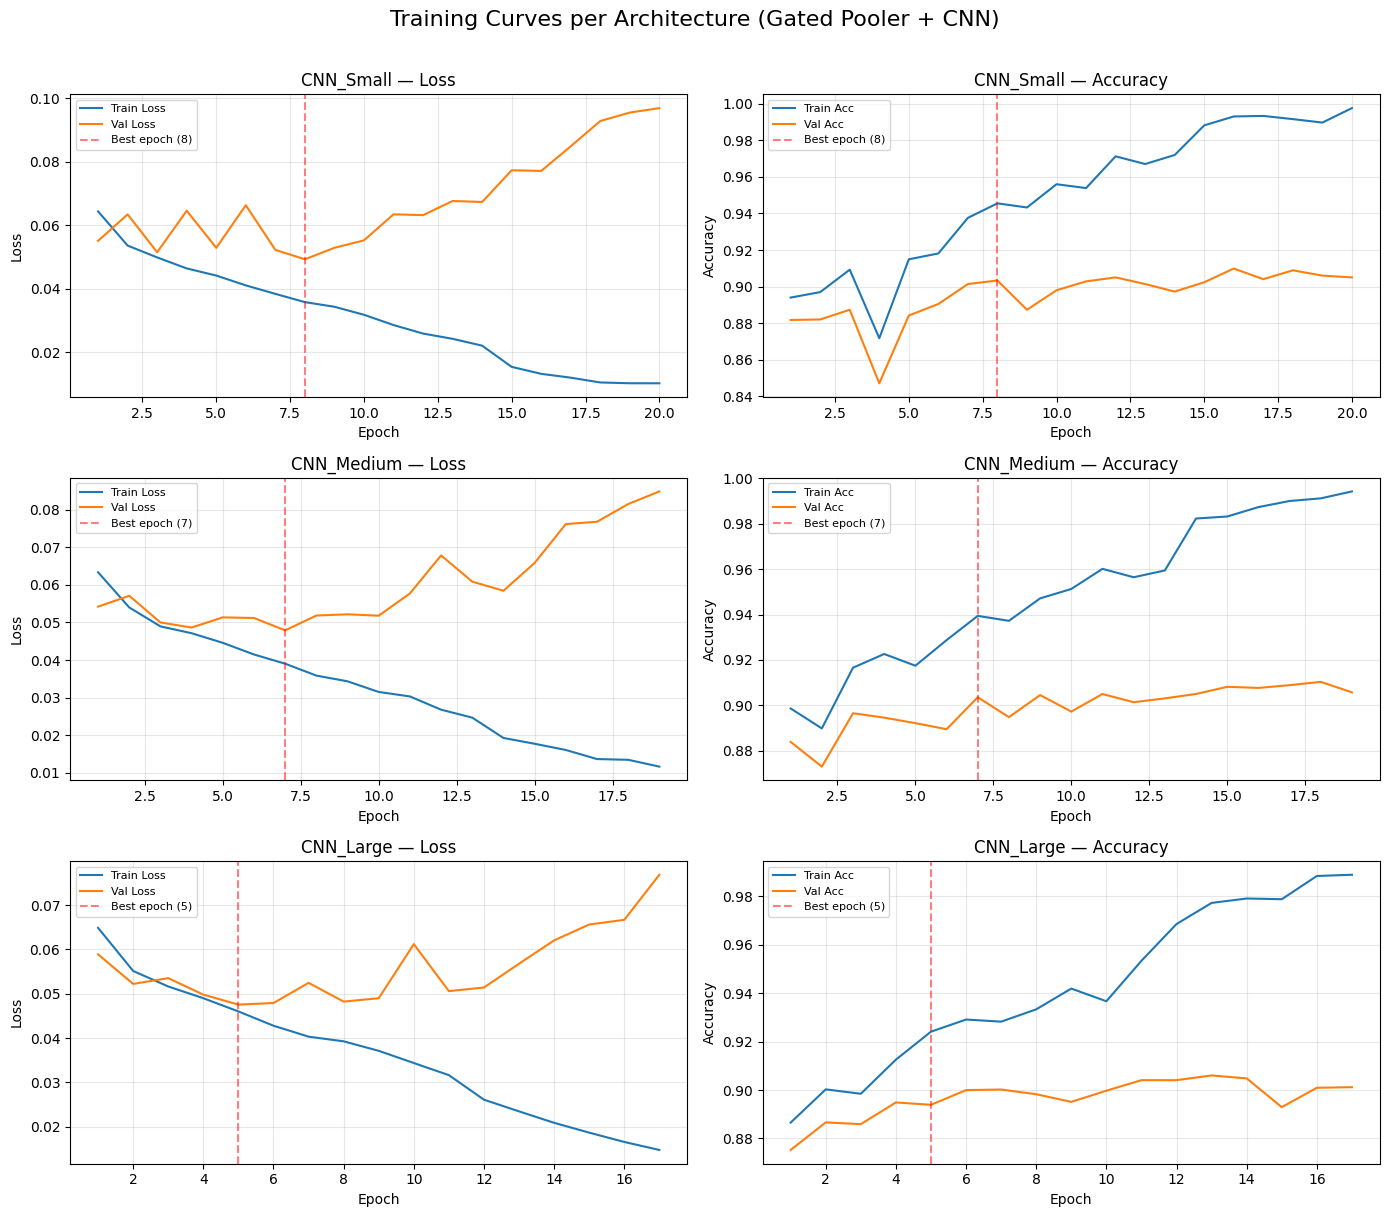

Saved: /kaggle/working/training_curves_individual.png


In [20]:
n_models = len(all_results)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 4 * n_models), squeeze=False)

for idx, r in enumerate(all_results):
    h = r["history"]
    epochs = h["epoch"]

    ax_loss = axes[idx, 0]
    ax_loss.plot(epochs, h["train_loss"], label="Train Loss", linewidth=1.5)
    ax_loss.plot(epochs, h["val_loss"], label="Val Loss", linewidth=1.5)
    ax_loss.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({r['best_epoch']})")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.set_title(f"{r['name']} — Loss")
    ax_loss.legend(fontsize=8)
    ax_loss.grid(True, alpha=0.3)

    ax_acc = axes[idx, 1]
    ax_acc.plot(epochs, h["train_acc"], label="Train Acc", linewidth=1.5)
    ax_acc.plot(epochs, h["val_acc"], label="Val Acc", linewidth=1.5)
    ax_acc.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({r['best_epoch']})")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_title(f"{r['name']} — Accuracy")
    ax_acc.legend(fontsize=8)
    ax_acc.grid(True, alpha=0.3)

fig.suptitle("Training Curves per Architecture (Gated Pooler + CNN)", fontsize=16, y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves_individual.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'training_curves_individual.png'}")

## 📈 Visualización: Curvas comparativas conjuntas

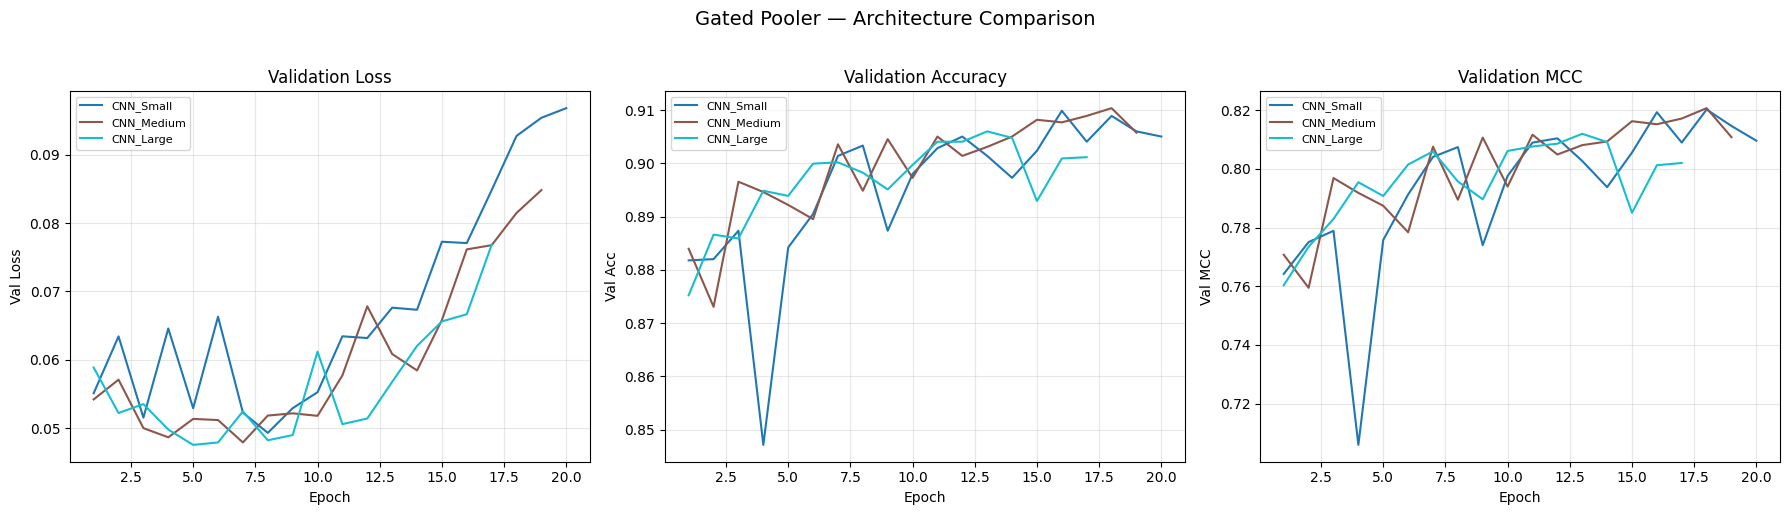

Saved: /kaggle/working/training_curves_comparison.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.tab10(np.linspace(0, 1, n_models))

for idx, r in enumerate(all_results):
    h = r["history"]
    axes[0].plot(h["epoch"], h["val_loss"], label=r["name"], color=colors[idx], linewidth=1.5)
    axes[1].plot(h["epoch"], h["val_acc"], label=r["name"], color=colors[idx], linewidth=1.5)
    axes[2].plot(h["epoch"], h["val_mcc"], label=r["name"], color=colors[idx], linewidth=1.5)

# Eje 0: Loss
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Val Loss"); axes[0].set_title("Validation Loss")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Eje 1: Accuracy
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val Acc"); axes[1].set_title("Validation Accuracy")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

# ✅ Eje 2: MCC 
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Val MCC"); axes[2].set_title("Validation MCC")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

fig.suptitle("Gated Pooler — Architecture Comparison", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'training_curves_comparison.png'}")

## 📊 Visualización: Gráfico de Barras Comparativo

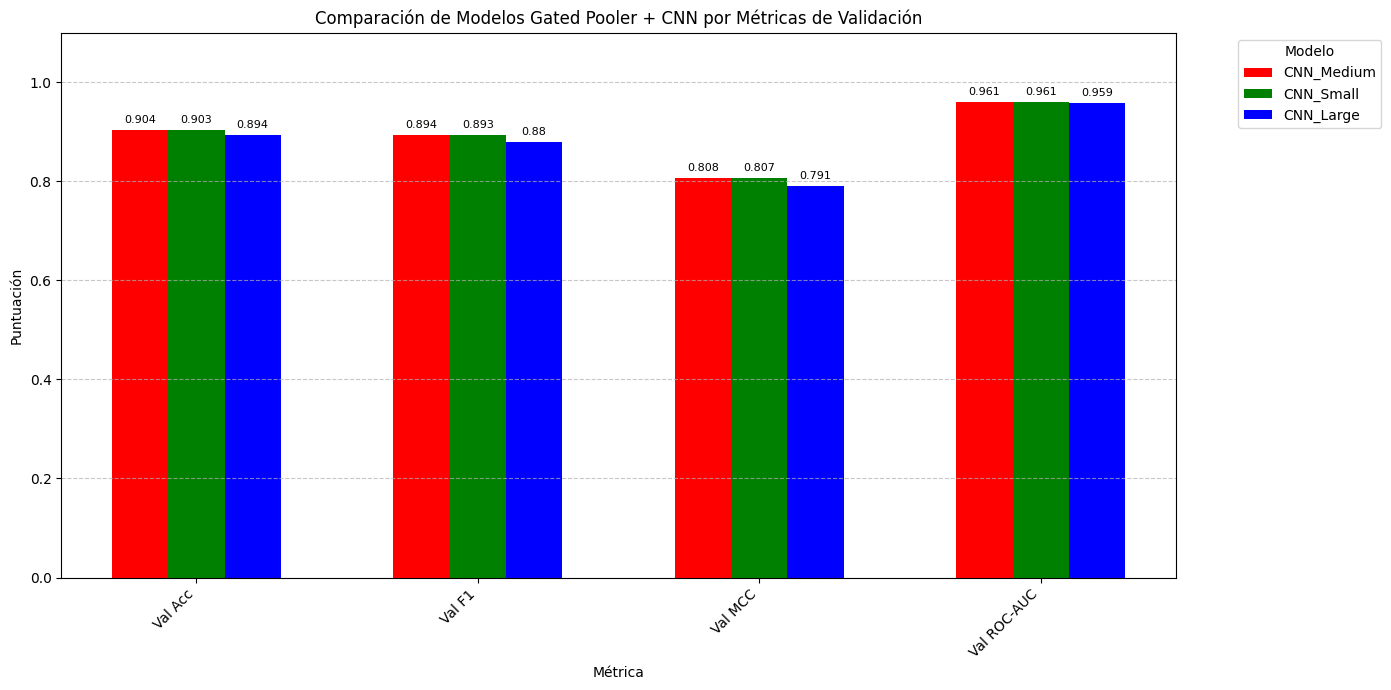

Saved: /kaggle/working/model_metrics_comparison_bar_chart.png


In [22]:
metric_cols = ["Val Acc", "Val F1", "Val MCC", "Val ROC-AUC"]
model_names = summary_df['Model'].tolist()

fig, ax = plt.subplots(figsize=(14, 7))
bar_width = 0.2
index = np.arange(len(metric_cols))
custom_colors = ['red', 'green', 'blue']

for i, model_name in enumerate(model_names):
    model_scores = summary_df[summary_df['Model'] == model_name][metric_cols].values.flatten()
    bars = ax.bar(index + i * bar_width, model_scores, bar_width, label=model_name, color=custom_colors[i % len(custom_colors)])
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 3),
                ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Métrica')
ax.set_ylabel('Puntuación')
ax.set_title('Comparación de Modelos Gated Pooler + CNN por Métricas de Validación')
ax.set_xticks(index + bar_width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metric_cols, rotation=45, ha='right')
ax.set_ylim(0, 1.1)
ax.legend(title='Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plot_path = OUT_DIR / "model_metrics_comparison_bar_chart.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")

## 💾 Guardado del Mejor Modelo y Artefactos

In [23]:
best_model = best_result["model"]
best_config = best_result["config"]

val_proba_final, val_y_final = predict_proba(best_model, val_loader, DEVICE)
val_metrics_final = compute_metrics(val_y_final, val_proba_final)

final_ckpt_path = OUT_DIR / "best_model_final.pth"
final_checkpoint = {
    "model_name": best_config["name"],
    "state_dict": best_model.state_dict(),
    "config": best_config,
    "input_dim": INPUT_DIM,
    "n_params": best_result["n_params"],
    "best_epoch": best_result["best_epoch"],
    "best_val_loss": best_result["best_val_loss"],
    "training_time_sec": best_result["training_time_sec"],
    "val_metrics": val_metrics_final,
    "history": best_result["history"],
    "hyperparameters": {
        "seed": SEED,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,
        "lr": best_config["lr"],
        "weight_decay": best_config["weight_decay"],
    },
}
torch.save(final_checkpoint, final_ckpt_path)

history_df = pd.DataFrame(best_result["history"])
history_path = OUT_DIR / "best_model_training_log.csv"
history_df.to_csv(history_path, index=False)

metrics_path = OUT_DIR / "best_model_val_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(val_metrics_final, f, indent=2)

print(f"\n🏆 Best model: {best_config['name']}")
print(f"   Parameters: {best_result['n_params']:,}")
print(f"   Best epoch: {best_result['best_epoch']}")
print(f"   Val loss:   {best_result['best_val_loss']:.6f}")
print(f"\nSaved:")
print(f"  Checkpoint:    {final_ckpt_path}")
print(f"  Training log:  {history_path}")
print(f"  Val metrics:   {metrics_path}")


🏆 Best model: CNN_Medium
   Parameters: 1,584,578
   Best epoch: 7
   Val loss:   0.047899

Saved:
  Checkpoint:    /kaggle/working/best_model_final.pth
  Training log:  /kaggle/working/best_model_training_log.csv
  Val metrics:   /kaggle/working/best_model_val_metrics.json


## 🏆 Conclusión: el mejor modelo

Tras completar el proceso de experimentación, se concluye que la configuración **CNN_Medium** ofrece el mejor rendimiento entre las arquitecturas CNN con **Gated Pooling + AAontology** evaluadas, según la métrica de validación **MCC**.

### Resultados destacados

| Métrica       | Valor  |
|---------------|--------|
| Mejor modelo  | CNN_Medium |
| Parámetros    | 1,584,578 |
| Mejor época   | 7 |
| Val loss      | 0.0479 |
| Val Accuracy  | 0.9036 |
| Val F1        | 0.8935 |
| Val MCC       | 0.8112 |
| Val ROC-AUC   | 0.9603 |

### Análisis

- **Capacidad de aprendizaje:** las convoluciones 1D capturan patrones locales en los embeddings, mientras que el gating guiado por AAontology pondera los residuos más relevantes.
- **Generalización:** `CNN_Medium` alcanzó el mejor MCC y un ROC-AUC alto, mostrando una convergencia estable y buena transferencia a validación.
- **Eficiencia:** con aproximadamente 1.58M parámetros, ofrece un equilibrio sólido entre capacidad expresiva y costo computacional frente a `CNN_Large`.

**Estado final:** el modelo ha sido exportado como `best_model_final.pth`, quedando listo para su evaluación externa o integración en el pipeline de validación final.